<a href="https://colab.research.google.com/github/roughhawkbit/digi-inno-road-prod/blob/main/analysis/Analyse_BART_DRS_predictions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [1]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

In [2]:
import matplotlib
import numpy
import os
import pandas
import scipy
import sklearn
import statsmodels.api
import sys

In [3]:
if IN_COLAB:
  dirpath = '/content/digi-inno-road-prod'
  if not os.path.isdir(dirpath):
    # TODO git pull
    !git clone https://github.com/roughhawkbit/digi-inno-road-prod.git
  sys.path.insert(0,dirpath)
else:
  module_path = os.path.abspath(os.path.join('..'))
  if not module_path in sys.path:
      sys.path.insert(0, module_path)

Cloning into 'digi-inno-road-prod'...
remote: Enumerating objects: 697, done.
remote: Counting objects: 100% (113/113), done.
remote: Compressing objects: 100% (106/106), done.
remote: Total 697 (delta 73), reused 14 (delta 7), pack-reused 584 (from 1)
Receiving objects: 100% (697/697), 1.97 MiB | 21.00 MiB/s, done.
Resolving deltas: 100% (438/438), done.


In [4]:
from innoprod.digital_readiness_score import DRS_LEVELS
from innoprod.sheet_tools import get_sheet_dfs
from innoprod.plotting_tools import rand_jitter

# Read in data

In [23]:
bart_drs_predictions_df = get_sheet_dfs(
    sheet_id="1hi2l8WiY98VUrR6XfxI8w9cOgfxgfuqSvA7S95-fH3M",
    ranges={"Results": "Sheet1!A1:F473"}
  )['Results']
# bart_drs_predictions_df

In [24]:
col_types = {
    'Client ID': 'str',
    'Current Digital Readiness Score (refer to PAS:1040)': pandas.Int64Dtype(),
    'Number of GAFs': 'int',
    'Predicted DRS': 'int',
    'Probability': 'float',
    'Confidence': 'float'
}

bart_drs_predictions_df['Current Digital Readiness Score (refer to PAS:1040)'] = bart_drs_predictions_df['Current Digital Readiness Score (refer to PAS:1040)'].replace(to_replace='', value=numpy.nan)

for col, ty in col_types.items():
  bart_drs_predictions_df[col] = bart_drs_predictions_df[col].astype(ty)

# Analysis

In [25]:
bart_drs_predictions_df['Current Digital Readiness Score (refer to PAS:1040)'].value_counts().sort_index()

,count
Current Digital Readiness Score (refer to PAS:1040),
1,19
2,45
3,66
4,100
5,121
6,79
7,28
8,12
9,2


In [26]:
bart_drs_predictions_df['Predicted DRS'].value_counts().sort_index()

,count
Predicted DRS,
1,9
2,11
3,13
4,116
5,203
6,11
7,44
8,64
9,1


Text(0.5, 0, 'Digital Readiness Score')

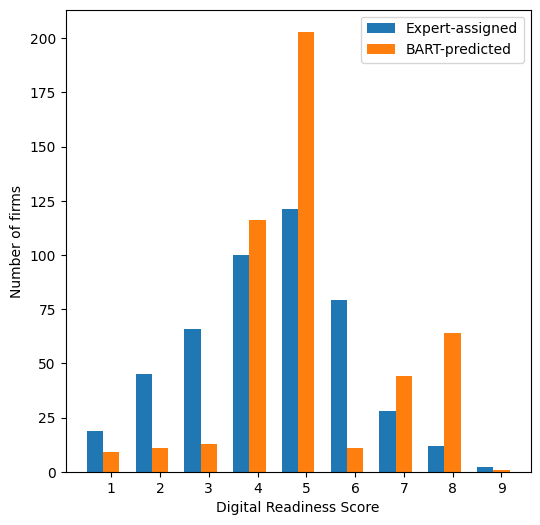

In [27]:
x = numpy.arange(1, len(DRS_LEVELS)+1)
width = 1/3

fig, ax = matplotlib.pyplot.subplots(figsize=(6,6))

multiplier = -1

for col, label in {'Current Digital Readiness Score (refer to PAS:1040)': 'Expert-assigned', 'Predicted DRS': 'BART-predicted'}.items():
  y = bart_drs_predictions_df[col].value_counts()
  y = y.reindex(range(1, len(DRS_LEVELS)+1), fill_value=0)
  offset = width * multiplier
  rects = ax.bar(
      x + offset,
      y,
      width,
      label=label
  )
  multiplier += 1

ax.set_xticks(x)

ax.legend()

ax.set_ylabel('Number of firms')
ax.set_xlabel('Digital Readiness Score')

## Direct comparison

In [28]:
bart_drs_predictions_df[['Current Digital Readiness Score (refer to PAS:1040)', 'Predicted DRS']].corr()

,Current Digital Readiness Score (refer to PAS:1040),Predicted DRS
Current Digital Readiness Score (refer to PAS:1040),1.000000,0.167885
Predicted DRS,0.167885,1.000000


In [29]:
def calculate_accuracy(df, max_diff):
  diffs = (df['Current Digital Readiness Score (refer to PAS:1040)'] - df['Predicted DRS']).abs()
  return (diffs <= max_diff).mean(skipna=True)

print(f'Accuracy: {calculate_accuracy(bart_drs_predictions_df, 0)}')
print(f'Adjacent accuracy: {calculate_accuracy(bart_drs_predictions_df, 1)}')

Accuracy: 0.2266949152542373
Adjacent accuracy: 0.5635593220338984


In [30]:
comparison_df = bart_drs_predictions_df.groupby(['Current Digital Readiness Score (refer to PAS:1040)', 'Predicted DRS']).size().reset_index(name='count')
heat = numpy.zeros((9,9))
heat[
      comparison_df['Current Digital Readiness Score (refer to PAS:1040)'].to_numpy()-1,
      comparison_df['Predicted DRS'].to_numpy()-1
    ] = comparison_df['count'].to_numpy().T
heat = heat.T
heat

array([[ 0.,  1.,  1.,  5.,  1.,  1.,  0.,  0.,  0.],
       [ 0.,  2.,  0.,  1.,  4.,  3.,  1.,  0.,  0.],
       [ 2.,  1.,  2.,  1.,  6.,  0.,  0.,  0.,  1.],
       [ 4., 15., 27., 27., 23., 14.,  2.,  3.,  1.],
       [12., 17., 25., 44., 57., 40.,  5.,  3.,  0.],
       [ 0.,  1.,  2.,  2.,  1.,  4.,  1.,  0.,  0.],
       [ 1.,  1.,  0.,  4., 11., 10., 13.,  4.,  0.],
       [ 0.,  7.,  9., 15., 18.,  7.,  6.,  2.,  0.],
       [ 0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.]])

In [31]:
lr_model = sklearn.linear_model.LinearRegression()
# Check reshaping
X = bart_drs_predictions_df.dropna()['Current Digital Readiness Score (refer to PAS:1040)'].to_numpy().reshape(-1, 1)
Y = bart_drs_predictions_df.dropna()['Predicted DRS'].to_numpy()
lr_model.fit(X, Y)

LinearRegression()

In [32]:
lr_model.score(X, Y)

0.028185430343684925

Text(0, 1.01, 'Number\nof firms')

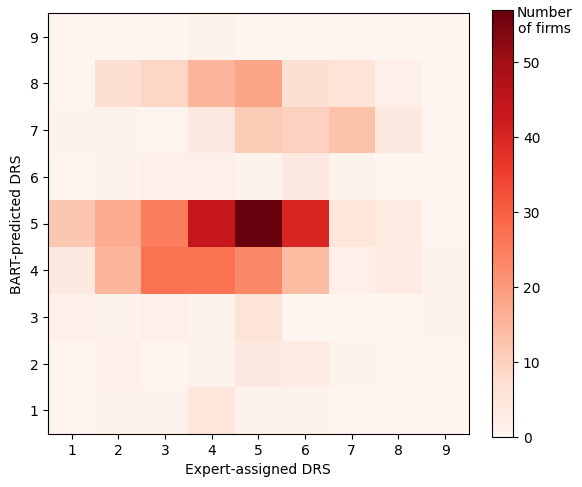

In [33]:
fig, ax = matplotlib.pyplot.subplots(figsize=(6,6))

im = ax.imshow(heat, cmap="Reds")

ax.xaxis.set_inverted(False)
ax.yaxis.set_inverted(False)

ax.set_xlabel('Expert-assigned DRS')
ax.set_ylabel('BART-predicted DRS')

ax.set_xticks(range(0,9), labels=[str(i) for i in range(1,10)])
ax.set_yticks(range(0,9), labels=[str(i) for i in range(1,10)])

cbar = ax.figure.colorbar(im, ax=ax, fraction=0.046)
cbar.ax.set_ylabel("Number\nof firms", rotation=0, y=1.01, labelpad=3)

In [34]:
bart_drs_predictions_df['Prediction diff'] = bart_drs_predictions_df['Current Digital Readiness Score (refer to PAS:1040)'] - bart_drs_predictions_df['Predicted DRS']
pred_diff_counts = bart_drs_predictions_df.groupby('Prediction diff').size().reset_index(name='count')
pred_diff_counts

,Prediction diff,count
0,-6,8
1,-5,11
2,-4,28
3,-3,45
4,-2,62
5,-1,89
6,0,107
7,1,70
8,2,27
9,3,14


In [35]:
bart_drs_predictions_df['Pred 5 diff'] = bart_drs_predictions_df['Current Digital Readiness Score (refer to PAS:1040)'] - 5
pred_5_diff_counts = bart_drs_predictions_df.groupby('Pred 5 diff').size().reset_index(name='count')
pred_5_diff_counts

,Pred 5 diff,count
0,-4,19
1,-3,45
2,-2,66
3,-1,100
4,0,121
5,1,79
6,2,28
7,3,12
8,4,2


Text(0, 0.5, 'Count')

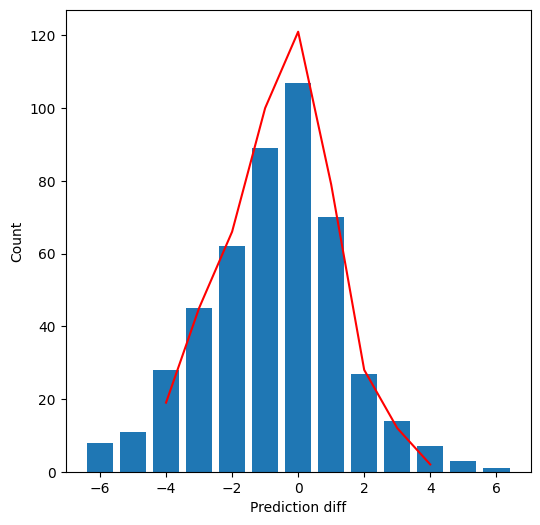

In [36]:
fig, ax = matplotlib.pyplot.subplots(figsize=(6,6))

ax.bar(pred_diff_counts['Prediction diff'], pred_diff_counts['count'])
ax.plot(pred_5_diff_counts['Pred 5 diff'], pred_5_diff_counts['count'], c='r')


ax.set_xlabel('Prediction diff')
ax.set_ylabel('Count')


In [37]:
bart_drs_predictions_df['Prediction diff'].mean()

np.float64(-0.7372881355932204)

In [38]:
bart_drs_predictions_df['Prediction diff'].std()

np.float64(2.0726833837734633)

<Axes: ylabel='Density'>

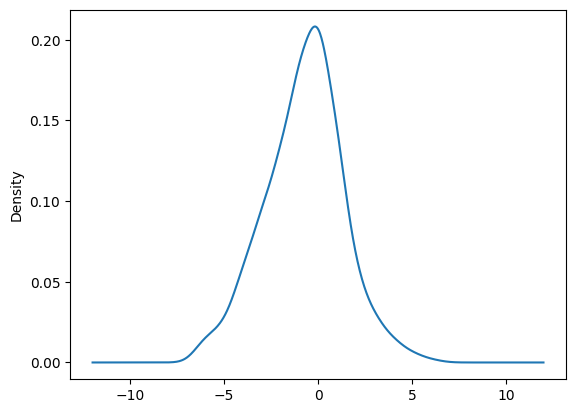

In [39]:
bart_drs_predictions_df['Prediction diff'].plot.density()

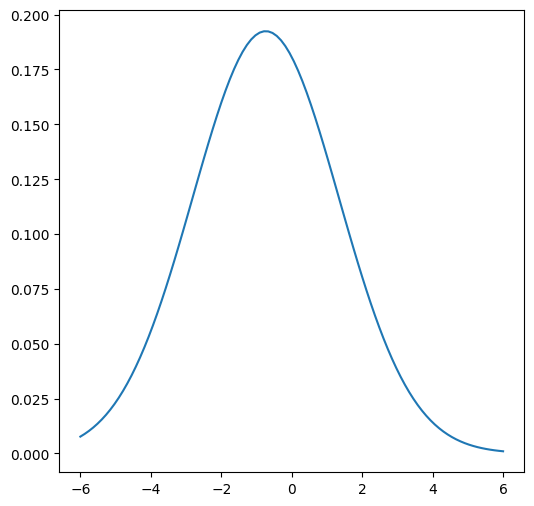

In [40]:
x = numpy.linspace(bart_drs_predictions_df['Prediction diff'].min(), bart_drs_predictions_df['Prediction diff'].max(), 100)
pred_diff_norm_pdf = scipy.stats.norm.pdf(
    x,
    loc=bart_drs_predictions_df['Prediction diff'].mean(),
    scale=bart_drs_predictions_df['Prediction diff'].std()
  )
fig, ax = matplotlib.pyplot.subplots(figsize=(6,6))
ax.plot(x, pred_diff_norm_pdf)